In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Fix for the 'CatBoostClassifier' object has no attribute '__sklearn_tags__' error
if not hasattr(CatBoostClassifier, '__sklearn_tags__'):
    def __sklearn_tags__(self):
        return {"classifier_only": True, "requires_fit": True, "X_types": ["2darray", "pandas"], "allow_nan": True}
    CatBoostClassifier.__sklearn_tags__ = __sklearn_tags__

In [7]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

le = LabelEncoder()
target = 'Heart Disease'
train_df[target] = le.fit_transform(train_df[target])

# Separate features from the label
X = train_df.drop(columns=['id', target])
y = train_df[target]
X_test = test_df.drop(columns=['id'])

In [8]:

# Load data
train = pd.read_csv('train.csv')

# 1. Integrity Check
print("--- Dataset Overview ---")
print(train.info())
print("\n--- Missing Values ---")
print(train.isnull().sum())

# 2. Statistical Summary
print("\n--- Numerical Feature Statistics ---")
display(train.describe().T)
import seaborn as sns
print(sns.__version__)

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 no

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,630000.0,54.136706,8.256301,29.0,48.00,54.0,60.00,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.00,1.0,1.00,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.00,4.0,4.00,4.0
BP,630000.0,130.497433,14.975802,94.0,120.00,130.0,140.00,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.00,243.0,269.00,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.00,0.0,0.00,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.00,0.0,2.00,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.00,157.0,166.00,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.00,0.0,1.00,1.0


0.13.2


In [26]:
train

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


In [38]:
## Feb 17th
import pandas as pd
import numpy as np

def create_heart_features(df):

    df = df.copy()

    # Quantile binning
    df['Chol_bin'] = pd.qcut(df['Cholesterol'], q=10, labels=False, duplicates='drop')

    # Interactions
    df['Age_MaxHR'] = df['Age'] * df['Max HR']
    df['Stress_Index'] = df['Age'] * df['ST depression']
    df['Vessel_Thal'] = df['Number of vessels fluro'] * df['Thallium']

    # Ratios
    df['ST_by_HR'] = df['ST depression'] / df['Max HR'].replace(0, np.nan)
    df['Chol_per_age'] = df['Cholesterol'] / df['Age'].replace(0, np.nan)
    df['HR_per_age'] = df['Max HR'] / df['Age'].replace(0, np.nan)

    # Fill ratio NaN
    ratio_cols = ['ST_by_HR','Chol_per_age','HR_per_age']
    df[ratio_cols] = df[ratio_cols].fillna(0)

    # Medical risk features
    df['Chol_risk'] = (df['Cholesterol'] > 240).astype(int)
    df['ST_severe'] = (df['ST depression'] > 2).astype(int)
    df['Age_risk'] = (df['Age'] > 55).astype(int)

    # HR reserve
    df['HR_reserve'] = 220 - df['Age'] - df['Max HR']

    # Log transforms
    df['Chol_log'] = np.log1p(df['Cholesterol'])
    df['BP_log'] = np.log1p(df['BP'])

    # ST bin
    bins = np.arange(0, 6.2 + 0.5, 0.5)

    df['ST_dep_bin'] = pd.cut(
        df['ST depression'],
        bins=bins,
        labels=False,
        include_lowest=True
    )
    df['Age_bin'] = pd.cut( df['Age'], bins=10, labels=False )
    df['HR_bin'] = pd.qcut(
    df['Max HR'],
    q=10,
    labels=False,
    duplicates='drop')
    return df


X = create_heart_features(X)
X_test = create_heart_features(X_test)




In [39]:
### Updated Preprocessor (Feb 18th)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


# =========================
# Numerical columns
# =========================

num_cols = [

    # original
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression',

    # interactions
    'Age_MaxHR',
    'Stress_Index',
    'Vessel_Thal',

    # ratios
    'ST_by_HR',
    'Chol_per_age',
    'HR_per_age',

    # medical engineered
    'HR_reserve',

    # logs
    'Chol_log',
    'BP_log',

]


# =========================
# Categorical columns
# =========================

cat_cols = [

    # original categorical
    'Chest pain type',
    'EKG results',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium',

    # engineered bins
    'Age_bin',
    'HR_bin',
    'Chol_bin',
    'ST_dep_bin',

]


# =========================
# Binary columns
# =========================

binary_cols = [

    # original binary
    'Sex',
    'FBS over 120',
    'Exercise angina',

    # engineered binary risk features
    'Chol_risk',
    'ST_severe',
    'Age_risk',

]


# =========================
# Preprocessor
# =========================

preprocessor = ColumnTransformer(

    transformers=[

        ('num', StandardScaler(), num_cols),

        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),

        ('bin', 'passthrough', binary_cols)

    ]

)


In [9]:
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
# Blueprint for numbers: Fill missing values with the middle (median) value, then scale them.
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Blueprint for categories: Fill missing values with the most common type, then assign a number code.
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine them into one 'Preprocessor'
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [12]:
# 5-Fold Cross-Validation: Split the data into 5 parts. 
# Train on 4 parts, test on 1 part. Repeat 5 times.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Starting 5-fold Cross-Validation...
Fold 1 ROC-AUC: 0.9558
Fold 2 ROC-AUC: 0.9547
Fold 3 ROC-AUC: 0.9556
Fold 4 ROC-AUC: 0.9551
Fold 5 ROC-AUC: 0.9560
------------------------------
Final Mean ROC-AUC: 0.9554 (+/- 0.0004)


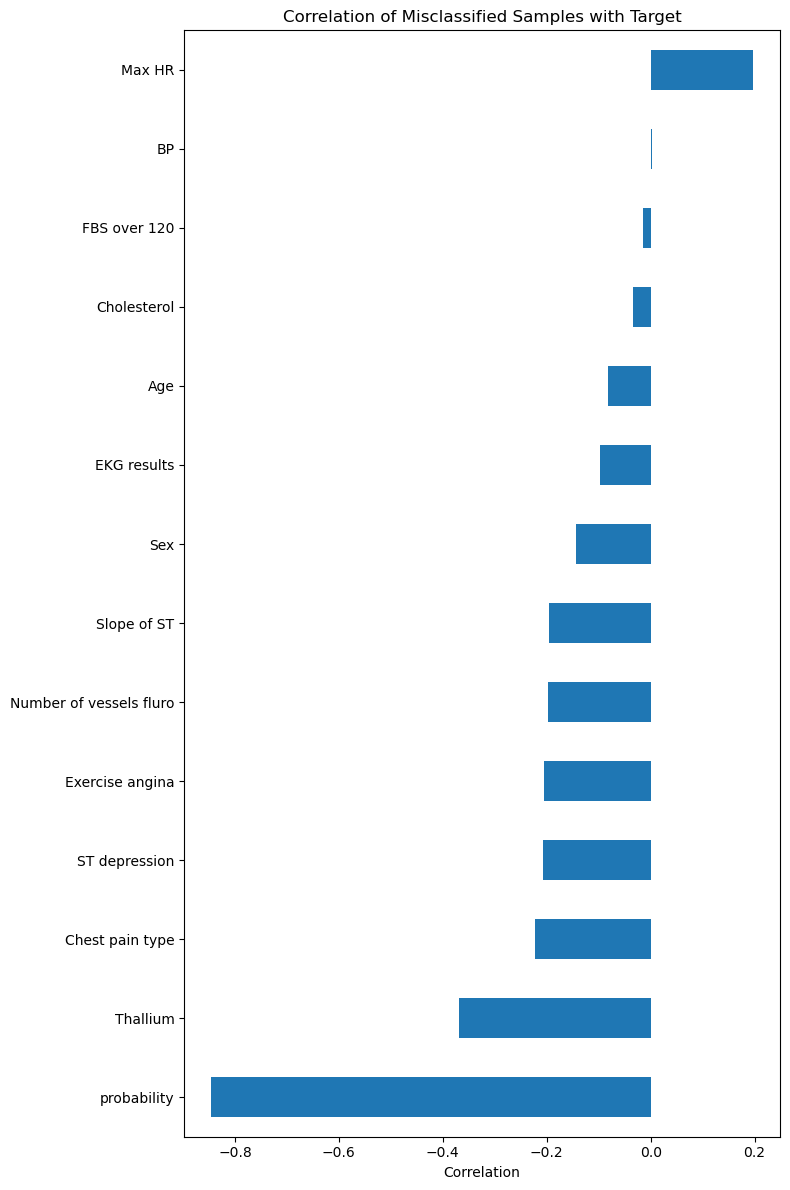

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Initialize storage
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

# NEW: store misclassified samples
misclassified_rows = []

# Feature importance storage
all_importances = []

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    model_pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf', CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            task_type='GPU',     # ✅ enables GPU
            depth=6,
            verbose=False,
            allow_writing_files=False
        ))
    ])
    
    model_pipeline.fit(X_train_fold, y_train_fold)

    # Feature importance
    feature_names = model_pipeline.named_steps['prep'].get_feature_names_out()
    importances = model_pipeline.named_steps['clf'].get_feature_importance()
    all_importances.append(importances)

    # Validation predictions
    val_probs = model_pipeline.predict_proba(X_val_fold)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Convert probs to class (0/1)
    val_preds = (val_probs >= 0.5).astype(int)

    # Find misclassified samples
    mis_mask = val_preds != y_val_fold.values
    X_mis = X_val_fold[mis_mask]
    y_mis = y_val_fold[mis_mask]

    # Store them
    mis_df = X_mis.copy()
    mis_df["target"] = y_mis.values
    mis_df["probability"]=val_probs[mis_mask]
    misclassified_rows.append(mis_df)

    # Fold score
    score = roc_auc_score(y_val_fold, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold+1} ROC-AUC: {score:.4f}")

    # Test predictions
    test_preds += model_pipeline.predict_proba(X_test)[:, 1] / skf.get_n_splits()

print('-' * 30)
print(f"Final Mean ROC-AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

# ============================
# ANALYZE MISCLASSIFIED ROWS
# ============================

misclassified_df = pd.concat(misclassified_rows)

# Correlation with target
corr_with_target = misclassified_df.corr(numeric_only=True)["target"].sort_values()

# Plot
plt.figure(figsize=(8, 12))
corr_with_target.drop("target").plot(kind="barh")
plt.title("Correlation of Misclassified Samples with Target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

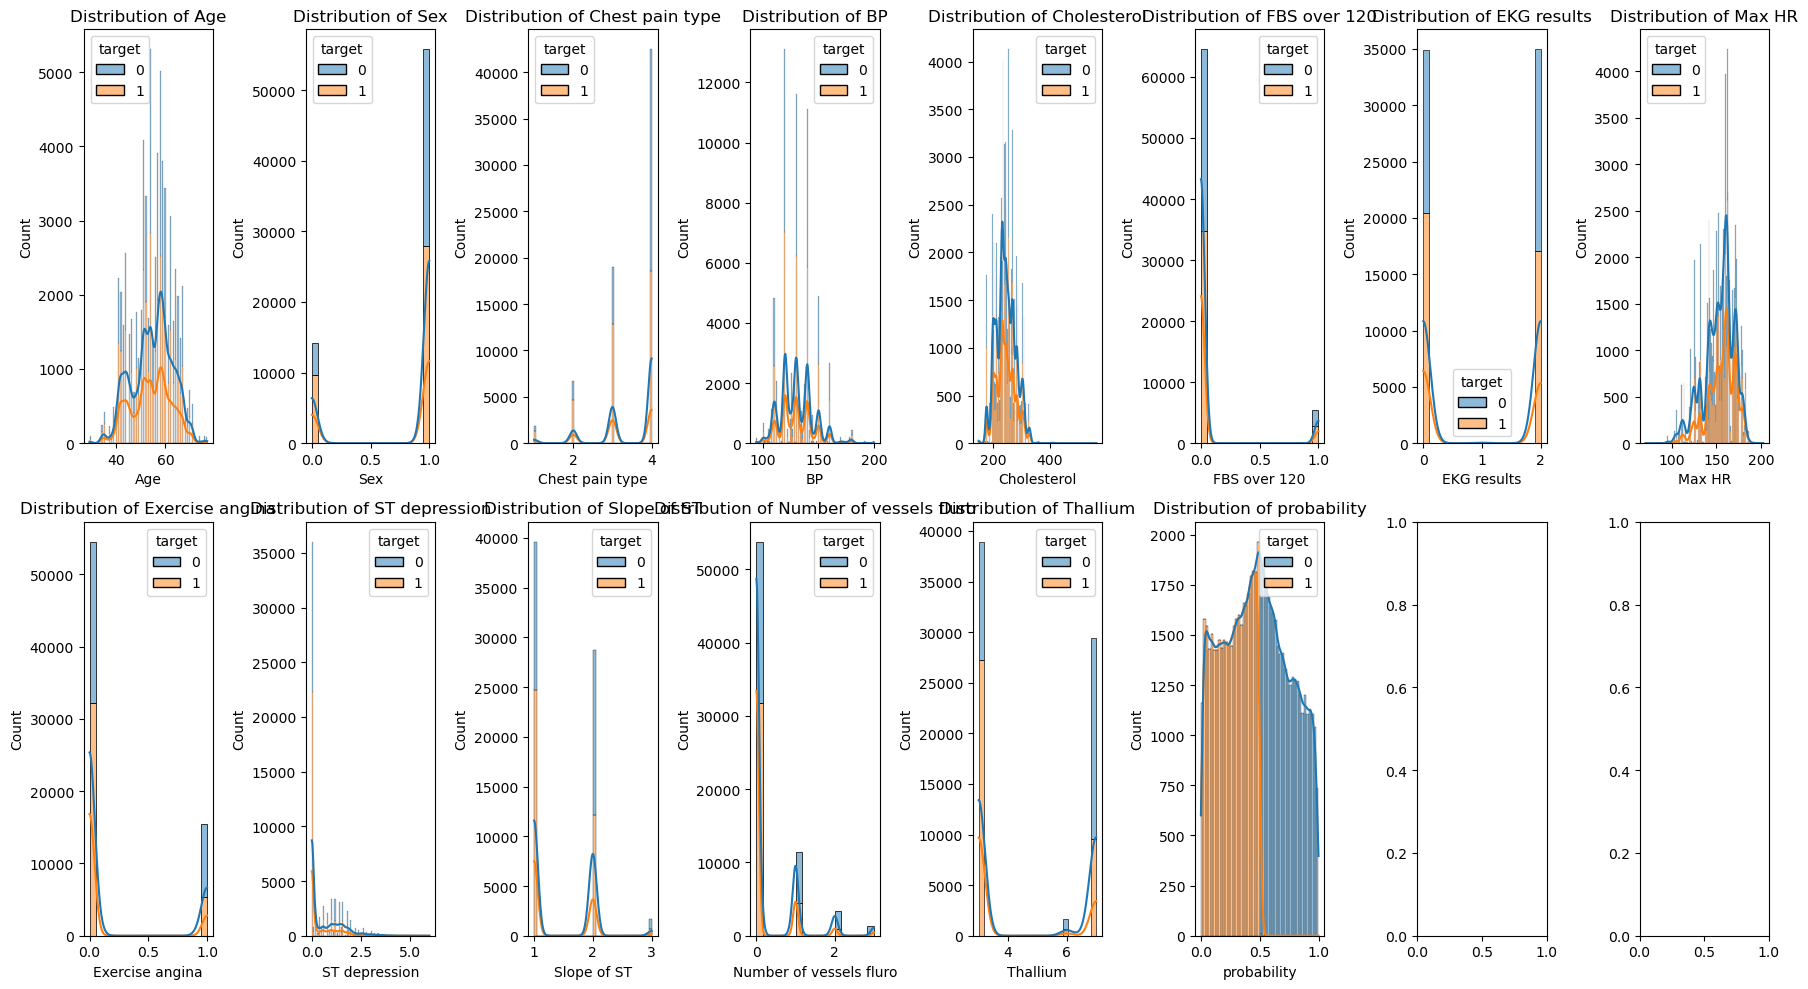

In [56]:

#num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
num_cols = ['Age',	'Sex',	'Chest pain type',	'BP',	'Cholesterol',	'FBS over 120',	'EKG results','Max HR',	'Exercise angina',	'ST depression',	'Slope of ST',	'Number of vessels fluro',	'Thallium','probability']

fig, axes = plt.subplots(2,8, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=misclassified_df, x=col, hue='target', kde=True, ax=axes[i], multiple="stack")
    axes[i].set_title(f'Distribution of {col}')

#fig.delaxes(axes[5]) # Remove the extra empty plot
plt.tight_layout()
plt.show()

In [53]:
# Create a DataFrame in the format required by the competition
submission = pd.DataFrame({
    'id': test_df['id'],            # Keep the original IDs
    'Heart Disease': test_preds,     # Use our averaged probability predictions
})

# Save to a CSV file
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' has been created successfully!")
# Display the first few rows to double check
print(submission.head())

Submission file 'submission.csv' has been created successfully!
       id  Heart Disease
0  630000       0.957918
1  630001       0.007122
2  630002       0.989609
3  630003       0.003832
4  630004       0.191971


In [44]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# storage
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]


    model_pipeline = Pipeline([

        ('prep', preprocessor),

        ('clf', lgb.LGBMClassifier(

            objective='binary',

            n_estimators=10000,
            learning_rate=0.01,

            num_leaves=64,

            subsample=0.8,
            colsample_bytree=0.8,

            reg_alpha=0.1,
            reg_lambda=0.1,

            random_state=42,

            n_jobs=-1

        ))

    ])


    model_pipeline.fit(

        X_train_fold,
        y_train_fold,

        clf__eval_set=[

            (
                preprocessor.transform(X_val_fold),
                y_val_fold
            )

        ],

        clf__eval_metric='auc',

        clf__callbacks=[

            lgb.early_stopping(200, verbose=False)

        ]

    )


    val_probs = model_pipeline.predict_proba(X_val_fold)[:, 1]

    oof_preds[val_idx] = val_probs


    score = roc_auc_score(y_val_fold, val_probs)

    fold_scores.append(score)

    print(f"Fold {fold+1} ROC-AUC: {score:.5f}")


    test_preds += (

        model_pipeline.predict_proba(X_test)[:, 1]
        / skf.get_n_splits()

    )


print('-' * 30)

print(

    f"Final Mean ROC-AUC: {np.mean(fold_scores):.5f} "
    f"(+/- {np.std(fold_scores):.5f})"

)


Starting 5-fold Cross-Validation...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2163
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Fold 1 ROC-AUC: 0.95536
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2156
[LightGBM] [Info] Number of data points in the

In [5]:
# ============================================
# IMPORTS
# ============================================

import numpy as np
import pandas as pd

from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


# ============================================
# SETTINGS
# ============================================

N_SPLITS = 5

#SEEDS = [42, 1337, 2025]
SEEDS = [42]

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)


# ============================================
# CATEGORICAL FEATURES
# ============================================

cat_features = [

    'Sex',
    'Chest pain type',
    'FBS over 120',
    'EKG results',
    'Exercise angina',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium'

]


# ============================================
# STORAGE
# ============================================

oof_global = np.zeros(len(X))

test_global = np.zeros(len(X_test))


oof_sex = np.zeros(len(X))

test_sex = np.zeros(len(X_test))


# ============================================
# GLOBAL MODEL
# ============================================

print("Training GLOBAL model")


for seed in SEEDS:

    print(f"\nSeed {seed}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]


        model = CatBoostClassifier(

            iterations=2000,
            learning_rate=0.02,
            depth=6,

            eval_metric='AUC',

            task_type='GPU',
            devices='0',

            random_state=seed,

            early_stopping_rounds=300,

            verbose=False

        )


        model.fit(

            X_train,
            y_train,

            cat_features=cat_features,

            eval_set=(X_val, y_val)

        )


        oof_global[val_idx] += (
            model.predict_proba(X_val)[:,1] / len(SEEDS)
        )


        test_global += (
            model.predict_proba(X_test)[:,1]
            / (N_SPLITS * len(SEEDS))
        )


score_global = roc_auc_score(y, oof_global)

print("GLOBAL CV:", score_global)


# ============================================
# SEX-SPECIFIC MODELS
# ============================================

print("\nTraining SEX-SPECIFIC models")


for seed in SEEDS:

    print(f"\nSeed {seed}")


    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):


        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]


        # split male/female

        male_train = X_train['Sex'] == 1
        female_train = X_train['Sex'] == 0

        male_val = X_val['Sex'] == 1
        female_val = X_val['Sex'] == 0


        model_male = CatBoostClassifier(

            iterations=2000,
            learning_rate=0.02,
            depth=6,

            eval_metric='AUC',

            task_type='GPU',

            random_state=seed,

            early_stopping_rounds=300,

            verbose=False

        )


        model_female = CatBoostClassifier(

            iterations=2000,
            learning_rate=0.02,
            depth=6,

            eval_metric='AUC',

            task_type='GPU',

            random_state=seed,

            early_stopping_rounds=300,

            verbose=False

        )


        # train

        model_male.fit(

            X_train[male_train],
            y_train[male_train],

            cat_features=cat_features

        )


        model_female.fit(

            X_train[female_train],
            y_train[female_train],

            cat_features=cat_features

        )


        # predict validation

        oof_sex[val_idx[male_val]] += (
            model_male.predict_proba(
                X_val[male_val]
            )[:,1] / len(SEEDS)
        )


        oof_sex[val_idx[female_val]] += (
            model_female.predict_proba(
                X_val[female_val]
            )[:,1] / len(SEEDS)
        )


        # predict test

        male_test = X_test['Sex'] == 1
        female_test = X_test['Sex'] == 0


        test_sex[male_test] += (
            model_male.predict_proba(
                X_test[male_test]
            )[:,1] / (N_SPLITS * len(SEEDS))
        )


        test_sex[female_test] += (
            model_female.predict_proba(
                X_test[female_test]
            )[:,1] / (N_SPLITS * len(SEEDS))
        )


score_sex = roc_auc_score(y, oof_sex)

print("SEX CV:", score_sex)


# ============================================
# FINAL ENSEMBLE
# ============================================

final_oof = (

    0.5 * oof_global +

    0.5 * oof_sex

)


final_test = (

    0.5 * test_global +

    0.5 * test_sex

)


final_score = roc_auc_score(y, final_oof)

print("\nFINAL CV:", final_score)


# ============================================
# SUBMISSION
# ============================================

submission = pd.DataFrame({

    "id": X_test["id"],

    "Heart Disease": final_test

})


submission.to_csv(

    "submission.csv",

    index=False

)


print("\nSubmission saved.")


Training GLOBAL model

Seed 42


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


GLOBAL CV: 0.955408679326119

Training SEX-SPECIFIC models

Seed 42


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


SEX CV: 0.9552108417051539

FINAL CV: 0.9553430236113472


KeyError: 'id'

Starting 5-fold CV with noise ensemble...

FOLD 1
Fold ROC-AUC: 0.83146

FOLD 2
Fold ROC-AUC: 0.83284

FOLD 3
Fold ROC-AUC: 0.83654

FOLD 4
Fold ROC-AUC: 0.83873

FOLD 5
Fold ROC-AUC: 0.83052

FINAL ROC-AUC: 0.83402
STD: 0.00312


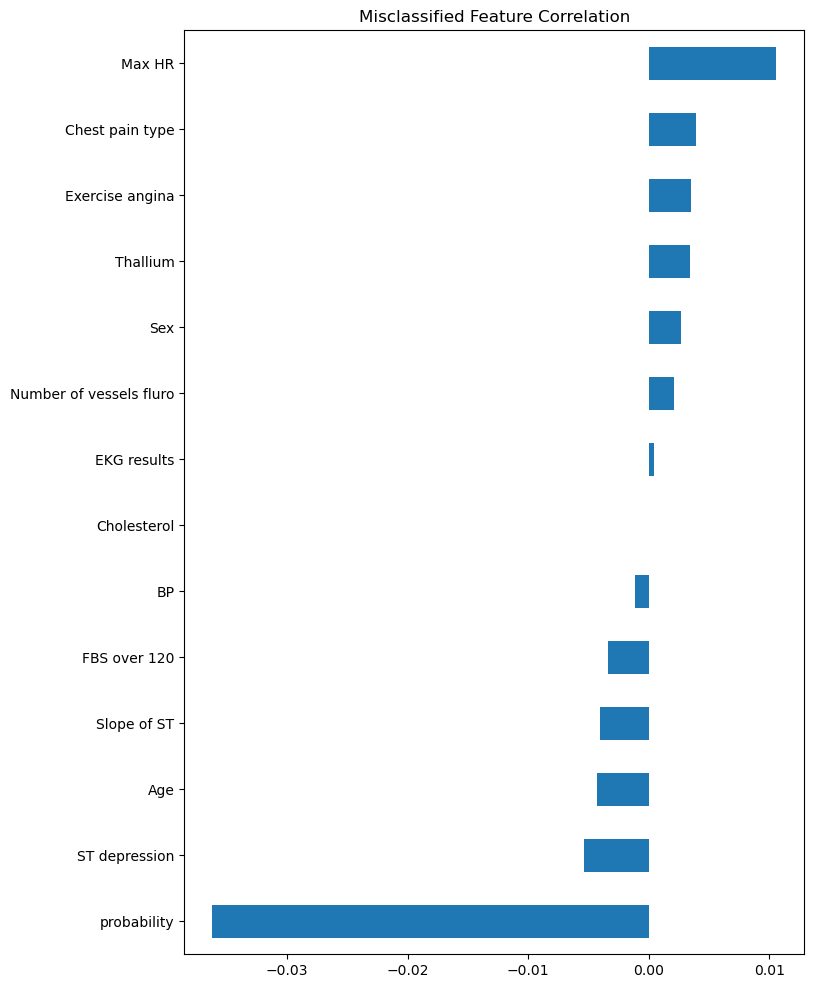


TOP FEATURES:
                         feature  importance
12                 cat__Thallium   18.546132
3                    num__Max HR   17.906908
6           cat__Chest pain type   16.856772
11  cat__Number of vessels fluro   10.665026
9           cat__Exercise angina    7.318538
4             num__ST depression    6.595880
10              cat__Slope of ST    6.501054
5                       cat__Sex    6.335468
0                       num__Age    4.153172
8               cat__EKG results    1.790844
2               num__Cholesterol    1.714131
1                        num__BP    1.062162
7              cat__FBS over 120    0.553914

Submission saved.


In [11]:
# ============================================================
# CATBOOST + NOISE ENSEMBLE + MISCLASS ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from catboost import CatBoostClassifier


# ============================================================
# CONFIG
# ============================================================

N_SPLITS = 5

NOISE_LEVEL = 0.01

SEEDS = [42, 1337, 2024]   # multi-seed ensemble


# ============================================================
# NOISE FUNCTION
# ============================================================

def add_noise(df, noise_level=0.01):

    df = df.copy()

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:

        std = df[col].std()

        if std > 0:

            noise = np.random.normal(

                0,

                noise_level * std,

                size=len(df)

            )

            df[col] += noise

    return df


# ============================================================
# STRATIFIED KFOLD
# ============================================================

skf = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=42

)


# ============================================================
# STORAGE
# ============================================================

oof_preds = np.zeros(len(X))

test_preds = np.zeros(len(X_test))

fold_scores = []

misclassified_rows = []

all_importances = []


print(f"Starting {N_SPLITS}-fold CV with noise ensemble...")


# ============================================================
# CV LOOP
# ============================================================

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    print(f"\nFOLD {fold+1}")


    X_train_fold = X.iloc[train_idx]

    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]

    y_val_fold = y.iloc[val_idx]


    seed_val_preds = np.zeros(len(X_val_fold))

    seed_test_preds = np.zeros(len(X_test))


    # ========================================================
    # MULTI SEED TRAINING
    # ========================================================

    for seed in SEEDS:


        np.random.seed(seed)


        # add noise

        X_train_noisy = add_noise(

            X_train_fold,

            noise_level=NOISE_LEVEL

        )


        model_pipeline = Pipeline([

            ('prep', preprocessor),

            ('clf', CatBoostClassifier(

                iterations=1000,

                learning_rate=0.05,

                depth=6,

                task_type='GPU',

                random_seed=seed,

                verbose=False,

                allow_writing_files=False

            ))

        ])


        model_pipeline.fit(

            X_train_noisy,

            y_train_fold

        )


        # validation predictions

        val_probs = model_pipeline.predict_proba(

            X_val_fold

        )[:,1]


        seed_val_preds += val_probs / len(SEEDS)


        # test predictions

        seed_test_preds += model_pipeline.predict_proba(

            X_test

        )[:,1] / len(SEEDS)


        # feature importance

        importances = model_pipeline.named_steps['clf'].get_feature_importance()

        all_importances.append(importances)


    # store OOF

    oof_preds[val_idx] = seed_val_preds


    test_preds += seed_test_preds / N_SPLITS


    # score

    score = roc_auc_score(

        y_val_fold,

        seed_val_preds

    )


    fold_scores.append(score)


    print(f"Fold ROC-AUC: {score:.5f}")


    # ========================================================
    # MISCLASSIFIED ANALYSIS
    # ========================================================

    val_class = (seed_val_preds >= 0.5).astype(int)


    mis_mask = val_class != y_val_fold.values


    X_mis = X_val_fold[mis_mask]

    y_mis = y_val_fold[mis_mask]


    mis_df = X_mis.copy()

    mis_df["target"] = y_mis.values

    mis_df["probability"] = seed_val_preds[mis_mask]


    misclassified_rows.append(mis_df)



# ============================================================
# FINAL SCORE
# ============================================================

print("\n================================")

print(f"FINAL ROC-AUC: {np.mean(fold_scores):.5f}")

print(f"STD: {np.std(fold_scores):.5f}")

print("================================")


# ============================================================
# MISCLASSIFIED ANALYSIS
# ============================================================

misclassified_df = pd.concat(

    misclassified_rows

)


corr_with_target = misclassified_df.corr(

    numeric_only=True

)["target"].sort_values()


plt.figure(figsize=(8,12))

corr_with_target.drop("target").plot(

    kind="barh"

)

plt.title("Misclassified Feature Correlation")

plt.show()


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_names = preprocessor.get_feature_names_out()


mean_importance = np.mean(

    all_importances,

    axis=0

)


importance_df = pd.DataFrame({

    "feature": feature_names,

    "importance": mean_importance

})


importance_df = importance_df.sort_values(

    by="importance",

    ascending=False

)


print("\nTOP FEATURES:")

print(importance_df.head(20))


# ============================================================
# SAVE SUBMISSION
# ============================================================

submission = pd.DataFrame({

    "prediction": test_preds

})


submission.to_csv(

    "submission.csv",

    index=False

)


print("\nSubmission saved.")